In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(np.__version__)

2.3.5


In [2]:
#Load Data
CSV_DATA = 'food_prices.csv'

#adding filtered data
RECENT_DATA = 'food_price_2020_2026.csv'

new_df = pd.read_csv(RECENT_DATA)

df_raw = pd.read_csv(CSV_DATA)
print(f'totla records : {len(df_raw)}')
print(f'columns : {list(df_raw.columns)}' )
print(f'Date range : {df_raw["date"].min()} -> {df_raw["date"].max()}')

print(f'\nfirst 4 rows')

df_raw.head(4)

print(f'\nNEW_DATA: \n{new_df.head(5)}')


totla records : 79285
columns : ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']
Date range : 1990-10-15 -> 2026-04-15

first 4 rows

NEW_DATA: 
         date           region district       market  market_id  latitude  \
0  2020-11-15  Southern Region   Balaka  Balaka Boma        763    -14.99   
1  2020-12-15  Southern Region   Balaka  Balaka Boma        763    -14.99   
2  2021-01-15  Southern Region   Balaka  Balaka Boma        763    -14.99   
3  2021-02-15  Southern Region   Balaka  Balaka Boma        763    -14.99   
4  2021-03-15  Southern Region   Balaka  Balaka Boma        763    -14.99   

   longitude            category   commodity  commodity_id  unit  priceflag  \
0      34.96  cereals and tubers  Amaranthus           720  Heap  aggregate   
1      34.96  cereals and tubers  Amaranthus           720  Heap  aggregate   
2      34.96  cerea

In [3]:
#Check geographical coverage

print(f'\nRegions (admin1:)')
print(df_raw["admin1"].value_counts(dropna=False))

print(f'\nDistricts (admin2:)')
district = df_raw["admin2"].unique()
print(district)
print(f'\nDistricts: (admin2) - {df_raw["admin2"].nunique()} unique')

print(f'\n {sorted(df_raw["admin2"].dropna().unique())}')
len(df_raw["admin2"].dropna().unique())


print(f'\nMarket : - {df_raw["market"].nunique()} unique')
# df_raw["market"].nunique()

print("\n")
print(f'\nRecords with coordinates: {df_raw[["latitude", "longitude"]].notna().all(axis=1).sum()}')
print(f'\nRecords without coordinates either x or y: {df_raw[["latitude", "longitude"]].isna().any(axis=1).sum()} ')
print(f'\nRecords without coordinates both x and y: {df_raw[["latitude","longitude"]].isna().all(axis=1).sum()}')


#____________CHECK COMMODITY COVERAGE____________
print(df_raw.groupby("category")["commodity"].nunique().to_string())
print('\n')
print(df_raw.groupby(["category", "commodity"]).size().reset_index(name='records').to_string(index=False))


Regions (admin1:)
admin1
Southern Region    41383
Central Region     25333
Northern Region    12080
NaN                  489
Name: count, dtype: int64

Districts (admin2:)
[nan 'Nsanje' 'Dowa' 'Lilongwe' 'Mchinji' 'Nkhotakota' 'Ntcheu' 'Ntchisi'
 'Chitipa' 'Karonga' 'Mzimba' 'Rumphi' 'Chikwawa' 'Machinga' 'Mangochi'
 'Thyolo' 'Salima' 'Nkhata Bay' 'Kasungu' 'Blantyre' 'Dedza' 'Balaka'
 'Lilongwe City' 'Chiradzulu' 'Mwanza' 'Blantyre City' 'Zomba City'
 'Mulanje' 'Neno' 'Zomba' 'Phalombe' 'Mzuzu City']

Districts: (admin2) - 31 unique

 ['Balaka', 'Blantyre', 'Blantyre City', 'Chikwawa', 'Chiradzulu', 'Chitipa', 'Dedza', 'Dowa', 'Karonga', 'Kasungu', 'Lilongwe', 'Lilongwe City', 'Machinga', 'Mangochi', 'Mchinji', 'Mulanje', 'Mwanza', 'Mzimba', 'Mzuzu City', 'Neno', 'Nkhata Bay', 'Nkhotakota', 'Nsanje', 'Ntcheu', 'Ntchisi', 'Phalombe', 'Rumphi', 'Salima', 'Thyolo', 'Zomba', 'Zomba City']

Market : - 130 unique



Records with coordinates: 78796

Records without coordinates either x or y

In [4]:
#___________DATA CLEANING____________________

#filter data only from 2020 - 2026 focus and category 

df = df_raw.copy()

#parse dates propery
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

#Keep only food category drop(non-food, fuels and exchange rate)
FOOD_CATEGORIES = [
    'cereals and tubers',
    'pulses and nuts',
    'meat, fish and eggs',
    'miscellaneous food',
    'oil and fats',
    'vegetables and fruits'
]

# df = df[df["category"].isin(FOOD_CATEGORIES)]
# print(f'after food category filter: {len(df)}')

#Filter data from 2020 -2026 and only food categorie

df_recent = df[
    (df["date"] >= '2020-01-01') &
    (df["date"] <= '2026-04-15') &
    (df["category"].isin(FOOD_CATEGORIES))
]
len(df_recent)
df_recent.to_csv("food_price_2020_2026.csv", index=False)

print(f'\nNew data frame filtered: {len(new_df)}')

df = new_df.copy()
len(df)

# Drop the "National Average" aggregated rows — we want market-level data

# only aggregated national average data

#    (We keep national average separately for benchmarking later)
df_national = df[df["market"] == 'National Average'].copy()
print(f'\n national average records kept separtetly: {len(df_national)} records')

df = df[df["market"] != "National Average"]
print(f'\nAfter removing national average: {len(df):,} records')

# 4. Drop rows with no district name (we need admin2 for spatial joins)
# df = df.dropna(subset=["admin2"])
print(f'After dropping no-district rows: {len(df):,} records')

# Drop rows with no price
df = df.dropna(subset=["price"])
print(f'After dropping no-price rows: {len(df):,} records')

# Standardise column names
df = df.rename(columns={
    'admin1': 'region',
    'admin2': 'district'
})


#print(df.columns.tolist())

# Sort by location + commodity + date — essential for time-series diff
df = df.sort_values(['district', 'market', 'commodity', 'date']).reset_index(drop=True)

print('\n Cleaning complete')
df[['date','region','district','market','commodity','category','price','latitude','longitude']].head(5)

print(df['unit'].value_counts())

print(df.groupby(['commodity', 'unit']).size().reset_index(name='count').to_string(index=False))

# we have the problem in units which might cause spike problems eg fish in malawi context are sold in heap no KG
# Fully standardised — safe for spike detection and price comparison
# first lets ovewrite the csv with new data 

df.to_csv("food_price_2020_2026.csv", index=False)


New data frame filtered: 39511

 national average records kept separtetly: 0 records

After removing national average: 39,511 records
After dropping no-district rows: 39,511 records
After dropping no-price rows: 39,511 records

 Cleaning complete
unit
KG       26642
Heap      5307
Unit      3414
Bunch     2506
L         1642
Name: count, dtype: int64
             commodity  unit  count
            Amaranthus  Heap    765
                 Beans    KG   3681
   Beans (new harvest)    KG    428
          Beans leaves  Heap    841
      Blackjack leaves  Heap    334
     Cabbage (chinese) Bunch    689
               Cassava    KG   1196
         Cowpea leaves  Heap    350
               Cowpeas    KG   3006
                  Eggs  Unit   1552
     Exotic vegetables    KG    622
          Fish (bonya)  Heap    915
        Fish (kapenta)  Heap    375
        Fish (matemba)  Heap    916
     Fish (small, dry)    KG    618
          Fish (usipa)  Heap    404
          Fish (utaka)  Heap    40

In [5]:
#______FOCUS  UNIT COLUMN DATA CLEANING___

print(df["unit"].value_counts())
print(f'\n')
df.groupby(["commodity","unit"]).size().reset_index(name="count")

# See every commodity + unit combination we need to fix
print(df.groupby(['commodity', 'unit'])['price'].agg(['count', 'mean', 'min', 'max']).round(0).to_string())

unit
KG       26642
Heap      5307
Unit      3414
Bunch     2506
L         1642
Name: count, dtype: int64


                              count     mean     min       max
commodity              unit                                   
Amaranthus             Heap     765    141.0    10.0    2000.0
Beans                  KG      3681   3259.0   362.0   13550.0
Beans (new harvest)    KG       428   6024.0  2975.0    7650.0
Beans leaves           Heap     841    179.0    10.0    1112.0
Blackjack leaves       Heap     334     57.0    10.0     100.0
Cabbage (chinese)      Bunch    689    132.0    11.0    3000.0
Cassava                KG      1196   1682.0   100.0    6000.0
Cowpea leaves          Heap     350     54.0    20.0     100.0
Cowpeas                KG      3006   2024.0     5.0    7500.0
Eggs                   Unit    1552    394.0    55.0    1000.0
Exotic vegetables      KG       622    822.0    81.0    4000.0
Fish (bonya)           Heap     915    906.0   100.0    2000.0
Fish (kape

In [6]:
# ── Approach: Two clean files ───────────────────────────────────────────────

# File 1: Standardised — KG and Litres only
# These are your spike detection and choropleth data
df_standard = df[df['unit'].isin(['KG', 'L'])].copy()

# Fix the one real problem — Groundnuts outlier
outlier_mask = (
    (df_standard['commodity'] == 'Groundnuts (shelled)') &
    (df_standard['price'] > 25000)
)
print(f'Groundnuts outliers removed: {outlier_mask.sum()} rows')
df_standard = df_standard[~outlier_mask]

# File 2: Informal — Heap, Bunch, Unit kept exactly as collected
df_informal = df[df['unit'].isin(['Heap', 'Bunch', 'Unit'])].copy()

# Add price index per commodity (% change from first observation)
# This lets you track trends WITHOUT converting units
df_informal = df_informal.sort_values(
    ['district', 'market', 'commodity', 'date']
).reset_index(drop=True)

df_informal['price_pct_change'] = (
    df_informal
    .groupby(['district', 'market', 'commodity'])['price']
    .pct_change() * 100
)

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== FILE 1: Standardised (KG + L) ===')
print(f'Records     : {len(df_standard):,}')
print(f'Commodities : {df_standard["commodity"].nunique()}')
print(sorted(df_standard["commodity"].unique()))

print('\n=== FILE 2: Informal (Heap + Bunch + Unit) ===')
print(f'Records     : {len(df_informal):,}')
print(f'Commodities : {df_informal["commodity"].nunique()}')
print(sorted(df_informal["commodity"].unique()))

# ── Save ──────────────────────────────────────────────────────────────────────
df_standard.to_csv('food_prices_standardised.csv', index=False)
df_informal.to_csv('food_prices_informal.csv', index=False)

print('\n✅ food_prices_standardised.csv → use for spike detection')
print('✅ food_prices_informal.csv     → use for informal market layer')

Groundnuts outliers removed: 1 rows
=== FILE 1: Standardised (KG + L) ===
Records     : 28,283
Commodities : 21
['Beans', 'Beans (new harvest)', 'Cassava', 'Cowpeas', 'Exotic vegetables', 'Fish (small, dry)', 'Groundnuts (shelled)', 'Local vegetables', 'Maize', 'Maize (new harvest)', 'Maize flour', 'Millet', 'Oil (vegetable)', 'Pigeon peas', 'Potatoes', 'Rice', 'Sorghum', 'Soybeans', 'Sugar', 'Sweet potatoes', 'Tomatoes']

=== FILE 2: Informal (Heap + Bunch + Unit) ===
Records     : 11,227
Commodities : 16
['Amaranthus', 'Beans leaves', 'Blackjack leaves', 'Cabbage (chinese)', 'Cowpea leaves', 'Eggs', 'Fish (bonya)', 'Fish (kapenta)', 'Fish (matemba)', 'Fish (usipa)', 'Fish (utaka)', 'Mustard leaves', 'Onions', 'Pumpkin leaves', 'Rape leaves', 'Tomatoes (medium size)']

✅ food_prices_standardised.csv → use for spike detection
✅ food_prices_informal.csv     → use for informal market layer


In [7]:


#_____________Spike Detection__________

#PRIMARY FILE
PRIMARY_FILE = "food_prices_standardised.csv"

df = pd.read_csv(PRIMARY_FILE)

# Group key: same market + same commodity time series
GROUP_KEY = ["district", "market", "commodity"]

# Method 1: Month-over-month percentage change
df["pct_change"] = df.groupby(GROUP_KEY)["price"].pct_change() * 100

# Method 2: Rolling z-score (12-month window)
# Z-score = (price - rolling_mean) / rolling_std
# A z-score > 2 means the price is 2 standard deviations above the rolling average

def rolling_zscore(series, window=12):
    roll = series.rolling(window, min_periods=3)
    return (series - roll.mean()) / roll.std()

df["zscore"] = df.groupby(GROUP_KEY)["price"].transform(rolling_zscore)

# Defining Spike thresholds (tunable)
PCT_SPIKE_THRESHOLD = 20 # 20% jump month-over-month
ZSCORE_THRESHOLD = 1.5   # 1.5 standard deviations above rolling mean

# Flag spike
df["is_spike"] = (
    (df['pct_change'] >= PCT_SPIKE_THRESHOLD) & # sudden jump
    (df['zscore'] >= ZSCORE_THRESHOLD)      # statistically normal
)

# Spike severity label
conditions = [
    (df['pct_change'] >= 60) & (df['zscore'] >= 2.5),
    (df['pct_change'] >= 40) & (df['zscore'] >= 2.0),
    (df['pct_change'] >= PCT_SPIKE_THRESHOLD) & (df['zscore'] >= ZSCORE_THRESHOLD)
]

choices = ["Critical", "Severe", "Moderate"]
df['spike_severity'] = np.select(conditions, choices, default='Normal')

# df[["price", "pct_change", "zscore","spike_severity"]].head(20)

print('=== SEVERITY DISTRIBUTION ===')
counts = df['spike_severity'].value_counts()
pcts   = (counts / len(df) * 100).round(2)

for sev in ['Critical','Severe','Moderate','Normal']:
    if sev in counts:
        print(f'{sev:<12}: {counts[sev]:>6,} rows  ({pcts[sev]}%)')

print(f'\nTotal spikes (Moderate+): {df[df["spike_severity"] != "Normal"].shape[0]:,}')

=== SEVERITY DISTRIBUTION ===
Critical    :    215 rows  (0.76%)
Severe      :    799 rows  (2.83%)
Moderate    :  1,581 rows  (5.59%)
Normal      : 25,688 rows  (90.82%)

Total spikes (Moderate+): 2,595


In [8]:
# the Critical spikes
critical = df[df["spike_severity"] == "Critical"].copy()

print('=== CRITICAL SPIKES BREAKDOWN ===\n')
print('By Region:')
print(critical['region'].value_counts())

print('\nBy District top10:')
print(critical['district'].value_counts().head(10))

print('\nBy Commodity top10:')
print(critical['commodity'].value_counts().head(10))

print('\nBy Year:')
print(critical['date'].value_counts().sort_index())

print('\nWorst single events (highest pct_change):')
print(critical.nlargest(10, 'pct_change')[
    ['date','district','market','commodity','price','pct_change','zscore']
].to_string(index=False))

=== CRITICAL SPIKES BREAKDOWN ===

By Region:
region
Southern Region    122
Central Region      58
Northern Region     35
Name: count, dtype: int64

By District top10:
district
Machinga    25
Zomba       21
Mulanje     13
Ntchisi     11
Nsanje      11
Chikwawa     9
Mzimba       9
Ntcheu       9
Balaka       9
Dowa         9
Name: count, dtype: int64

By Commodity top10:
commodity
Maize                   123
Maize (new harvest)      31
Pigeon peas              18
Cowpeas                  16
Beans                    13
Rice                      4
Sorghum                   2
Millet                    2
Sweet potatoes            2
Groundnuts (shelled)      1
Name: count, dtype: int64

By Year:
date
2022-05-15     1
2022-08-15    21
2022-09-15    20
2023-01-15     6
2023-02-15     1
2023-04-15     2
2023-06-15     2
2023-07-15     1
2023-09-15     6
2023-10-15     2
2023-12-15     2
2024-01-15     5
2024-02-15     6
2024-03-15     1
2024-05-15     1
2024-09-15     5
2024-10-15     1
2025-0

In [9]:
# District risk summary — this becomes choropleth colour data
district_risk = (
    df.groupby(['region', 'district'])
    .agg(
        total_records    = ('price', 'count'),
        total_spikes     = ('is_spike', 'sum'),
        critical_count   = ('spike_severity', lambda x: (x == 'Critical').sum()),
        severe_count     = ('spike_severity', lambda x: (x == 'Severe').sum()),
        moderate_count   = ('spike_severity', lambda x: (x == 'Moderate').sum()),
        avg_price        = ('price', 'mean'),
        avg_pct_change   = ('pct_change', 'mean'),
        worst_spike      = ('pct_change', 'max'),
    )
    .reset_index()
)

# Spike rate per district — % of months that had any spike
district_risk['spike_rate_pct'] = (
    district_risk['total_spikes'] / district_risk['total_records'] * 100
).round(2)

# Risk score — weighted composite
# Critical counts 3x, Severe 2x, Moderate 1x
district_risk['risk_score'] = (
    district_risk['critical_count'] * 3 +
    district_risk['severe_count']   * 2 +
    district_risk['moderate_count'] * 1
)

# Rank districts by risk
district_risk = district_risk.sort_values(
    'risk_score', ascending=False
).reset_index(drop=True)

district_risk['risk_rank'] = district_risk.index + 1

print('=== DISTRICT RISK RANKING ===\n')
print(district_risk[[
    'risk_rank','region','district',
    'critical_count','severe_count','moderate_count',
    'spike_rate_pct','risk_score'
]].to_string(index=False))

=== DISTRICT RISK RANKING ===

 risk_rank          region      district  critical_count  severe_count  moderate_count  spike_rate_pct  risk_score
         1 Southern Region      Machinga              25            79             203            9.85         436
         2 Southern Region       Mulanje              13            65             108           10.90         277
         3 Southern Region         Zomba              21            54              91            8.89         262
         4 Southern Region        Nsanje              11            41             137            9.39         252
         5 Southern Region      Chikwawa               9            47              96           11.37         217
         6  Central Region          Dowa               9            34             104            8.37         199
         7  Central Region        Ntcheu               9            45              68           10.04         185
         8  Central Region       Ntchisi         

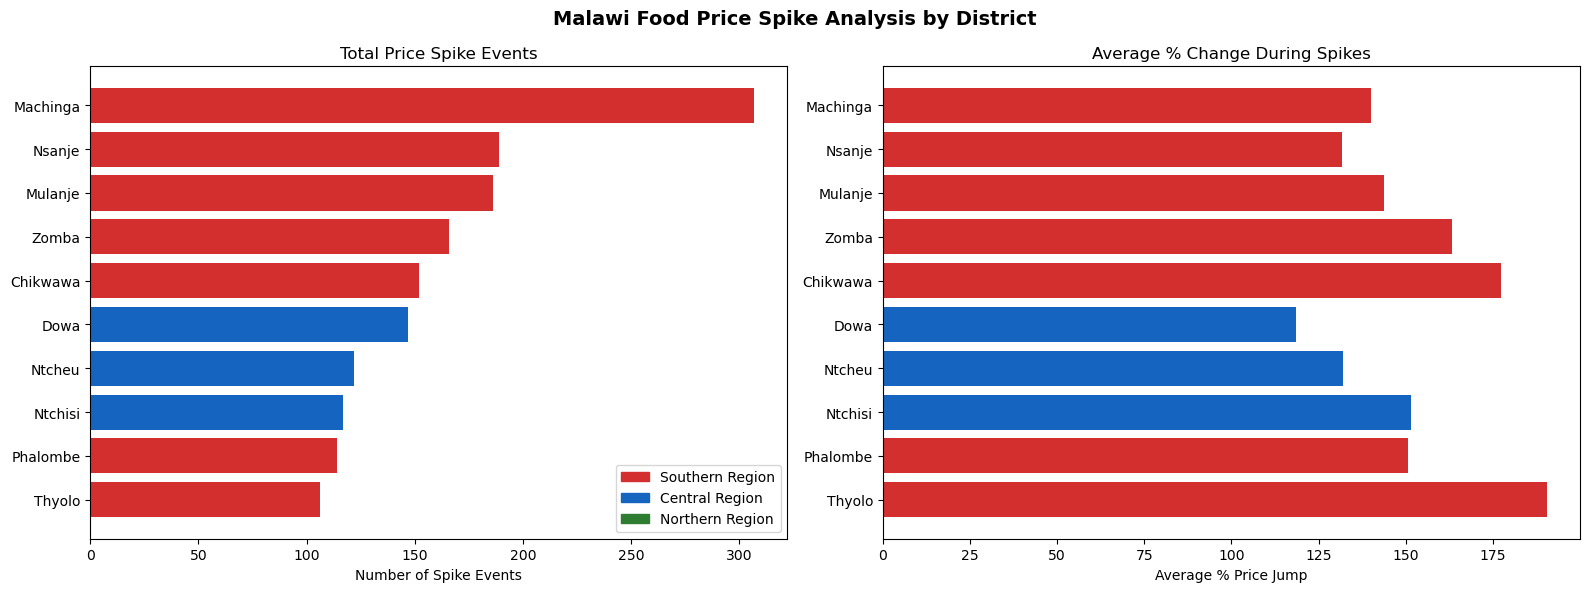

Chart saved as spike_by_district.png


In [10]:
# ── Visualise: Top 10 most volatile districts ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Malawi Food Price Spike Analysis by District', fontsize=14, fontweight='bold')

spike_by_district = df[df['spike_severity'] != 'Normal'] \
    .groupby(['district', 'region']) \
    .agg(
        total_spikes=('spike_severity', 'count'),
        avg_pct_change=('pct_change', 'mean')
    ) \
    .reset_index() \
    .sort_values(by='total_spikes', ascending=False)

top10 = spike_by_district.head(10)

# Bar chart: spike count
colors = ['#d32f2f' if r == 'Southern Region' else '#1565c0' if r == 'Central Region' else '#2e7d32'
          for r in top10['region']]
axes[0].barh(top10['district'], top10['total_spikes'], color=colors)
axes[0].set_xlabel('Number of Spike Events')
axes[0].set_title('Total Price Spike Events')
axes[0].invert_yaxis()

# Bar chart: avg pct change during spikes
axes[1].barh(top10['district'], top10['avg_pct_change'], color=colors)
axes[1].set_xlabel('Average % Price Jump')
axes[1].set_title('Average % Change During Spikes')
axes[1].invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#d32f2f', label='Southern Region'),
    Patch(color='#1565c0', label='Central Region'),
    Patch(color='#2e7d32', label='Northern Region'),
]
axes[0].legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('spike_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as spike_by_district.png')

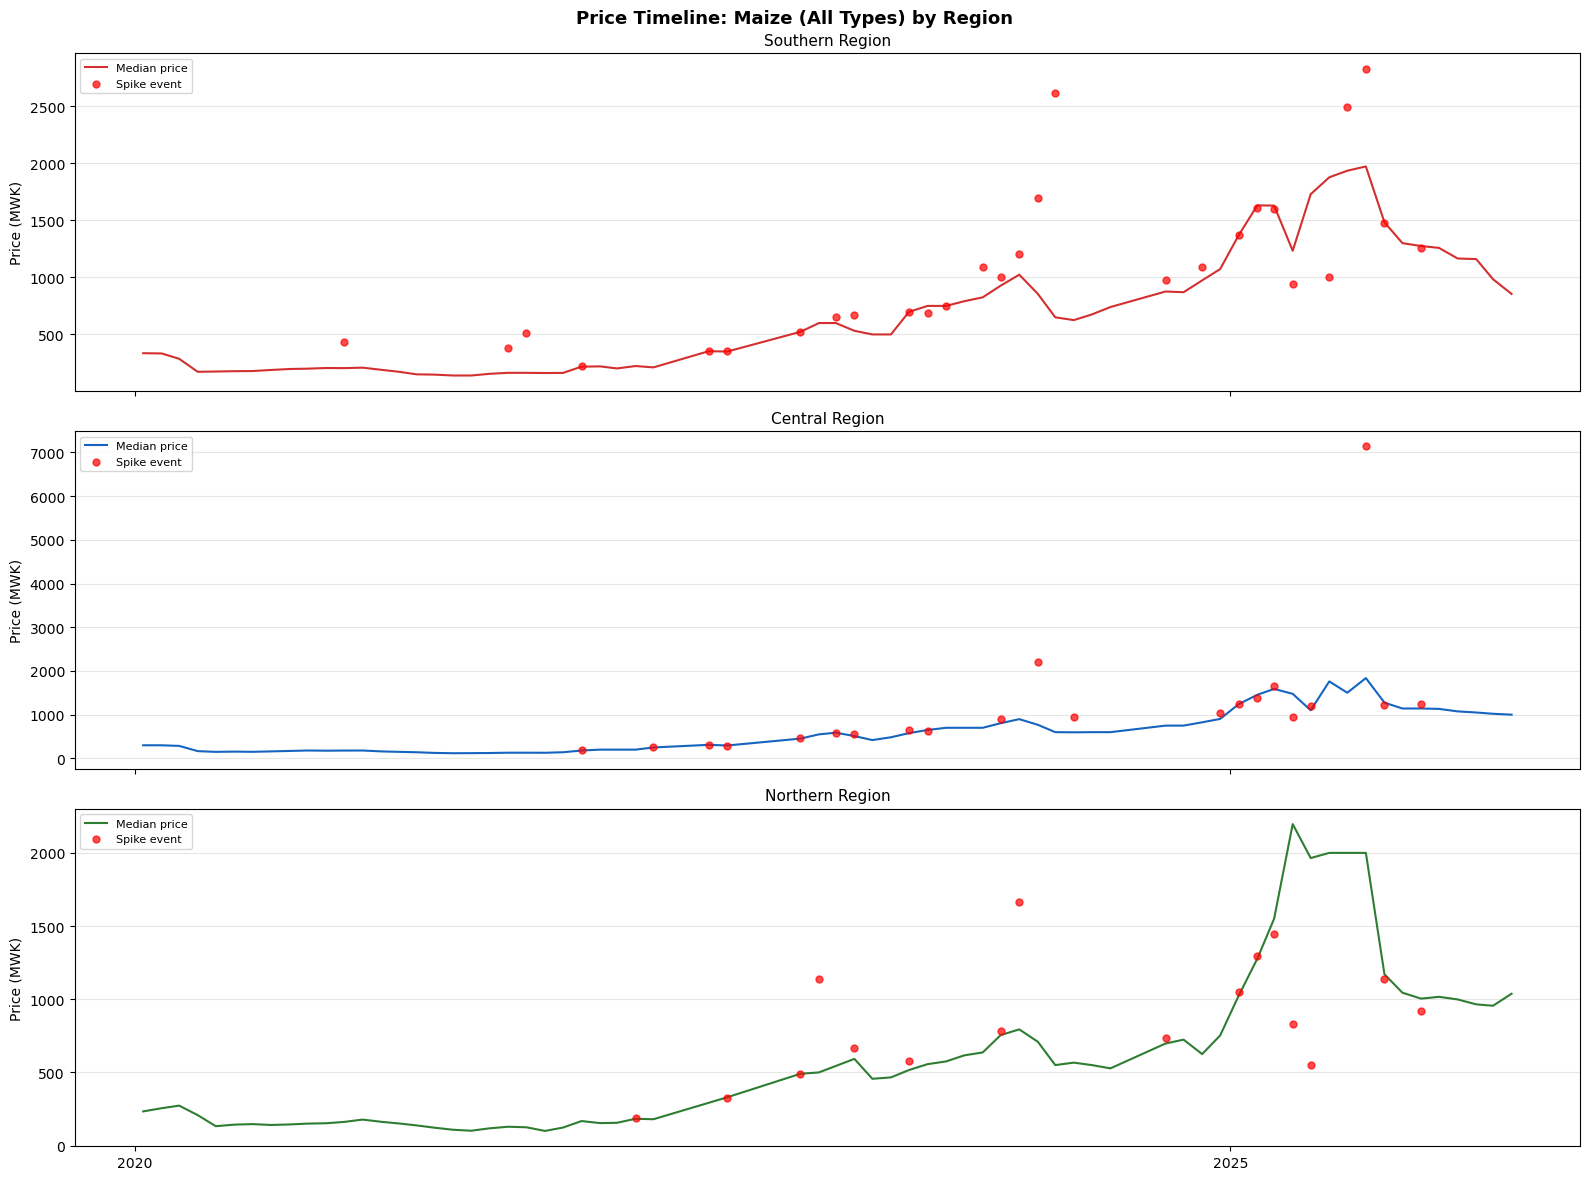

Chart saved as maize_price_timeline.png


In [18]:
# ── Visualise: Price timeline for one commodity across regions ─────────────────
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# ── Visualise: Price timeline for maize across regions ─────────────────
commodity_focus = 'maize'  # use flexible matching

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Price Timeline: Maize (All Types) by Region', fontsize=13, fontweight='bold')

regions = ['Southern Region', 'Central Region', 'Northern Region']
region_colors = ['#d32f2f', '#1565c0', '#2e7d32']

# Filter spike events
spikes = df[df['spike_severity'] != 'Normal'].copy()

for ax, region, color in zip(axes, regions, region_colors):
    
    # Filter maize-related data (case-insensitive)
    region_data = df[
        df['commodity'].str.contains(commodity_focus, case=False, na=False) &
        (df['region'] == region)
    ].groupby('date')['price'].median().reset_index()
    
    region_spikes = spikes[
        spikes['commodity'].str.contains(commodity_focus, case=False, na=False) &
        (spikes['region'] == region)
    ]

    # Plot price trend
    ax.plot(region_data['date'], region_data['price'],
            color=color, linewidth=1.5, label='Median price')

    # Overlay spike events
    if not region_spikes.empty:
        spike_monthly = region_spikes.groupby('date')['price'].median().reset_index()
        ax.scatter(spike_monthly['date'], spike_monthly['price'],
                   color='red', s=25, zorder=5, label='Spike event', alpha=0.7)

    ax.set_title(region, fontsize=11)
    ax.set_ylabel('Price (MWK)')
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('maize_price_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved as maize_price_timeline.png')

In [12]:
# The +838% Beans spike in Mchinji needs investigation
# before it goes on your map and misleads a decision maker

df['date'] = pd.to_datetime(df['date'])

suspicious = df[df['pct_change'] > 400].copy()
print('=== EVENTS ABOVE 400% — VERIFY BEFORE MAPPING ===\n')
print(suspicious[[
    'date','region','district','market',
    'commodity','price','pct_change','zscore'
]].to_string(index=False))
print(f'\nTotal suspicious events: {len(suspicious)}')

# Check what the price was BEFORE each suspicious spike
# to understand if it looks like a data error
for idx, row in suspicious.iterrows():
    prev = df[
        (df['district']  == row['district']) &
        (df['market']    == row['market']) &
        (df['commodity'] == row['commodity']) &
        (df['date']      < row['date'])
    ].tail(3)
    print(f"\n{row['market']} — {row['commodity']} — {row['date'].date()}")
    print(f"Spike price    : {row['price']:,.0f} MWK")
    print(f"Previous prices:")
    print(prev[['date','price']].to_string(index=False))

=== EVENTS ABOVE 400% — VERIFY BEFORE MAPPING ===

      date          region      district                market            commodity    price  pct_change    zscore
2026-01-15 Southern Region        Balaka           Balaka Boma     Local vegetables   800.00  700.000000  1.498349
2025-04-15 Southern Region        Balaka           Balaka Boma      Oil (vegetable)  8562.50  558.653846  2.266643
2025-04-15 Southern Region        Balaka           Balaka Boma                 Rice  4850.00  646.153846  2.473713
2026-02-15 Southern Region        Balaka                 Mbela     Local vegetables   600.00  500.000000  1.451813
2026-01-15 Southern Region        Balaka               Phalula     Local vegetables  1000.00  566.666667  1.494412
2025-05-15 Southern Region        Balaka               Ulongwe              Cassava  2400.00  585.714286  1.788854
2025-04-15 Southern Region        Balaka               Ulongwe      Oil (vegetable)  8427.08  666.098182  1.788689
2025-04-15 Southern Region   

In [13]:
# Save district risk ranking
district_risk.to_csv('malawi_district_risk.csv', index=False)
print('Saved: malawi_district_risk.csv')
print('   → This feeds choropleth map colours in Phase 5')

# Save spike events only
spikes = df[df['spike_severity'] != 'Normal'].copy()
spikes.to_csv('malawi_spikes_all.csv', index=False)
print(f'Saved: malawi_spikes_all.csv ({len(spikes):,} spike events)')

# Save critical only — your priority alert layer
critical = df[df['spike_severity'] == 'Critical'].copy()
critical.to_csv('malawi_spikes_critical.csv', index=False)
print(f'Saved: malawi_spikes_critical.csv ({len(critical):,} critical events)')

# Save full clean dataset with all new columns
df.to_csv('food_prices_analysed.csv', index=False)
print(f'Saved: food_prices_analysed.csv (complete dataset with spike flags)')

print('\n=== PHASE 1 COMPLETE — FILES PRODUCED ===')
print('''
food_prices_standardised.csv   → cleaned input data
food_prices_informal.csv       → informal market data  
malawi_district_risk.csv       → choropleth input (Phase 2 QGIS)
malawi_spikes_all.csv          → all spike events
malawi_spikes_critical.csv     → critical alerts only
food_prices_analysed.csv       → complete dataset with all flags
''')

Saved: malawi_district_risk.csv
   → This feeds choropleth map colours in Phase 5
Saved: malawi_spikes_all.csv (2,595 spike events)
Saved: malawi_spikes_critical.csv (215 critical events)
Saved: food_prices_analysed.csv (complete dataset with spike flags)

=== PHASE 1 COMPLETE — FILES PRODUCED ===

food_prices_standardised.csv   → cleaned input data
food_prices_informal.csv       → informal market data  
malawi_district_risk.csv       → choropleth input (Phase 2 QGIS)
malawi_spikes_all.csv          → all spike events
malawi_spikes_critical.csv     → critical alerts only
food_prices_analysed.csv       → complete dataset with all flags



In [14]:
import geopandas as gpd
from shapely.geometry import Point

# ── Load your analysed dataset ────────────────────────────────────────────────
df = pd.read_csv('food_prices_analysed.csv')
df['date'] = pd.to_datetime(df['date'])

# ── Market-level summary ──────────────────────────────────────────────────────
# One row per market — summarise all commodities tracked there
market_summary = (
    df.groupby(['region', 'district', 'market', 'latitude', 'longitude'])
    .agg(
        num_commodities  = ('commodity', 'nunique'),
        total_records    = ('price', 'count'),
        total_spikes     = ('is_spike', 'sum'),
        critical_count   = ('spike_severity', lambda x: (x == 'Critical').sum()),
        avg_price        = ('price', 'mean'),
        latest_date      = ('date', 'max'),
    )
    .reset_index()
)

# Spike rate per market
market_summary['spike_rate_pct'] = (
    market_summary['total_spikes'] / market_summary['total_records'] * 100
).round(2)

# Drop markets with no coordinates
market_summary = market_summary.dropna(subset=['latitude', 'longitude'])

print(f'Markets with coordinates: {len(market_summary)}')
print(f'Markets dropped (no coords): {df["market"].nunique() - len(market_summary)}')

# ── Convert to GeoDataFrame ───────────────────────────────────────────────────
# KEY CONCEPT: Point(longitude, latitude) — X first, then Y
# This matches the GIS convention: X = east-west, Y = north-south
geometry = [
    Point(lon, lat)
    for lon, lat in zip(market_summary['longitude'], market_summary['latitude'])
]

gdf_markets = gpd.GeoDataFrame(
    market_summary,
    geometry=geometry,
    crs='EPSG:4326'    # WGS84 — standard GPS coordinate system
)

print(f'\nGeoDataFrame created successfully')
print(f'CRS            : {gdf_markets.crs}')
print(f'Geometry type  : {gdf_markets.geom_type.unique()}')
print(f'Bounding box   : {gdf_markets.total_bounds}')
print(f'  [min_lon, min_lat, max_lon, max_lat]')
print(f'\nSample:')
print(gdf_markets[['district','market','num_commodities','total_spikes','geometry']].head(5))

Markets with coordinates: 113
Markets dropped (no coords): 0

GeoDataFrame created successfully
CRS            : EPSG:4326
Geometry type  : ['Point']
Bounding box   : [ 32.9  -17.12  35.87  -9.57]
  [min_lon, min_lat, max_lon, max_lat]

Sample:
  district        market  num_commodities  total_spikes              geometry
0    Dedza     Mtakataka               20             6  POINT (34.52 -14.23)
1    Dedza  Nsikawanjala               21            29  POINT (34.34 -14.39)
2    Dedza     Ntakataka               13            22  POINT (34.51 -14.22)
3    Dedza         Thete                4             0   POINT (34.08 -14.3)
4     Dowa     Dowa Boma               19             9  POINT (33.98 -13.68)


In [15]:
# ── Filter spike events only ──────────────────────────────────────────────────
spikes_df = df[df['spike_severity'] != 'Normal'].copy()
spikes_df  = spikes_df.dropna(subset=['latitude', 'longitude'])

print(f'Spike events with coordinates: {len(spikes_df):,}')

# ── Build geometry ────────────────────────────────────────────────────────────
spike_geometry = [
    Point(lon, lat)
    for lon, lat in zip(spikes_df['longitude'], spikes_df['latitude'])
]

# Select only the columns needed for the web map popup
# date must be string for GeoJSON — JSON has no datetime type
spike_cols = [
    'date', 'region', 'district', 'market',
    'commodity', 'price', 'pct_change', 'zscore', 'spike_severity'
]

gdf_spikes = gpd.GeoDataFrame(
    spikes_df[spike_cols].copy(),
    geometry=spike_geometry,
    crs='EPSG:4326'
)

# Convert date to string for GeoJSON compatibility
gdf_spikes['date'] = gdf_spikes['date'].astype(str)
gdf_spikes['pct_change'] = gdf_spikes['pct_change'].round(2)
gdf_spikes['zscore']     = gdf_spikes['zscore'].round(3)

# Severity breakdown
print(f'\nSpike severity in GeoDataFrame:')
print(gdf_spikes['spike_severity'].value_counts())

print(f'\nSample spike record:')
print(gdf_spikes[['district','market','commodity','price','pct_change','spike_severity','geometry']].head(3))

Spike events with coordinates: 2,595

Spike severity in GeoDataFrame:
spike_severity
Moderate    1581
Severe       799
Critical     215
Name: count, dtype: int64

Sample spike record:
   district       market commodity    price  pct_change spike_severity  \
7    Balaka  Balaka Boma     Beans  1500.00      100.00       Moderate   
21   Balaka  Balaka Boma     Beans  4000.00       33.33       Moderate   
23   Balaka  Balaka Boma     Beans  5229.17       30.73       Moderate   

                geometry  
7   POINT (34.96 -14.99)  
21  POINT (34.96 -14.99)  
23  POINT (34.96 -14.99)  


In [16]:
import folium
from folium.plugins import MarkerCluster

# ── Export GeoJSON files ──────────────────────────────────────────────────────
gdf_markets.to_file('malawi_markets.geojson', driver='GeoJSON')
print('✅ Saved: malawi_markets.geojson')
print('   → Open in QGIS: Layer > Add Layer > Add Vector Layer')

gdf_spikes.to_file('malawi_spikes.geojson', driver='GeoJSON')
print('✅ Saved: malawi_spikes.geojson')
print('   → Your spike alert layer — red markers on web map')

# ── Build Folium preview map ───────────────────────────────────────────────────
# Folium is Python-wrapped Leaflet — exactly what your Phase 5 web map will use
# This preview lets you verify your data is spatially correct before QGIS

m = folium.Map(
    location=[-13.5, 34.3],   # Centre of Malawi
    zoom_start=7,
    tiles='CartoDB positron'
)

# ── Layer 1: All markets as clustered blue dots ───────────────────────────────
cluster = MarkerCluster(name='All Markets').add_to(m)

for _, row in gdf_markets.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='#1565c0',
        fill=True,
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['market']}</b><br>"
            f"District   : {row['district']}<br>"
            f"Region     : {row['region']}<br>"
            f"Commodities: {row['num_commodities']}<br>"
            f"Spike rate : {row['spike_rate_pct']}%<br>"
            f"<b>Critical spikes: {row['critical_count']}</b>",
            max_width=250
        ),
        tooltip=row['market']
    ).add_to(cluster)

# ── Layer 2: Critical spikes as pulsing red markers ───────────────────────────
critical_layer = folium.FeatureGroup(name='Critical Spike Alerts')

gdf_critical = gdf_spikes[gdf_spikes['spike_severity'] == 'Critical']

for _, row in gdf_critical.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=9,
        color='#C0392B',
        fill=True,
        fill_color='#C0392B',
        fill_opacity=0.85,
        popup=folium.Popup(
            f"<b style='color:red'>CRITICAL SPIKE</b><br>"
            f"Market    : {row['market']}<br>"
            f"District  : {row['district']}<br>"
            f"Commodity : <b>{row['commodity']}</b><br>"
            f"Price     : {row['price']:,.0f} MWK<br>"
            f"Jump      : <b style='color:red'>+{row['pct_change']:.1f}%</b><br>"
            f"Z-score   : {row['zscore']}<br>"
            f"Date      : {row['date']}",
            max_width=260
        ),
        tooltip=f"CRITICAL: {row['commodity']} +{row['pct_change']:.0f}%"
    ).add_to(critical_layer)

critical_layer.add_to(m)

# ── Layer 3: Severe spikes ─────────────────────────────────────────────────────
severe_layer = folium.FeatureGroup(name='Severe Spike Alerts')

gdf_severe = gdf_spikes[gdf_spikes['spike_severity'] == 'Severe']

for _, row in gdf_severe.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color='#E67E22',
        fill=True,
        fill_color='#E67E22',
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b style='color:orange'>SEVERE SPIKE</b><br>"
            f"Market    : {row['market']}<br>"
            f"Commodity : <b>{row['commodity']}</b><br>"
            f"Price     : {row['price']:,.0f} MWK<br>"
            f"Jump      : +{row['pct_change']:.1f}%<br>"
            f"Date      : {row['date']}",
            max_width=240
        ),
        tooltip=f"SEVERE: {row['commodity']} +{row['pct_change']:.0f}%"
    ).add_to(severe_layer)

severe_layer.add_to(m)

# ── Layer control — toggle layers on/off ──────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

# ── Save and display ──────────────────────────────────────────────────────────
m.save('malawi_food_price_map.html')
print('✅ Saved: malawi_food_price_map.html')
print('   → Open this file in Firefox to preview your web map')
print()
print('=== PHASE 1 TRULY COMPLETE ===')
print('''
Files produced:
  malawi_markets.geojson        → market point layer (QGIS + Leaflet)
  malawi_spikes.geojson         → spike alert layer  (QGIS + Leaflet)
  malawi_district_risk.csv      → choropleth input   (QGIS join)
  malawi_spikes_critical.csv    → 215 critical events
  food_prices_analysed.csv      → complete dataset
  malawi_food_price_map.html    → interactive preview map

Next: Phase 2 — QGIS + GADM district boundaries
  Download: gadm.org → Malawi → Shapefile → gadm41_MWI_2.shp
''')

# Display inline in Jupyter
m

✅ Saved: malawi_markets.geojson
   → Open in QGIS: Layer > Add Layer > Add Vector Layer
✅ Saved: malawi_spikes.geojson
   → Your spike alert layer — red markers on web map
✅ Saved: malawi_food_price_map.html
   → Open this file in Firefox to preview your web map

=== PHASE 1 TRULY COMPLETE ===

Files produced:
  malawi_markets.geojson        → market point layer (QGIS + Leaflet)
  malawi_spikes.geojson         → spike alert layer  (QGIS + Leaflet)
  malawi_district_risk.csv      → choropleth input   (QGIS join)
  malawi_spikes_critical.csv    → 215 critical events
  food_prices_analysed.csv      → complete dataset
  malawi_food_price_map.html    → interactive preview map

Next: Phase 2 — QGIS + GADM district boundaries
  Download: gadm.org → Malawi → Shapefile → gadm41_MWI_2.shp

